In [2]:
import os
import sys
sys.path.append("/home/amirabbas-kazeminia/Projects/DeepRT")
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

from Model.deeprt import DeepRT
model = DeepRT.load_from_checkpoint("/home/amirabbas-kazeminia/Projects/DeepRT/weights/1layers_2heads_24dim_10seed.ckpt")

In [3]:
import pandas as pd
data = pd.read_csv("../data/ML_DATA.csv")
data_ = data.T.to_dict()
mapping = {datapoint["Peptide"]:datapoint['B'] for datapoint in data_.values()}
sequences = data["Peptide"].to_list()

In [4]:
pairs = []
threshold = 2
for seq in sequences:
    if seq[0]=="f" and seq[-2:]=="Kf":
        pair0 = seq
        pair1 = "F"+seq[1:-1]+"F"
        if pair1 in sequences:
            if abs(mapping[pair0]-mapping[pair1])>threshold:
                pairs.append((pair0, pair1))
    elif seq[0]=='f' and seq[-1]=='R':
        pair0 = seq
        pair1 = "F"+seq[1:]
        if pair1 in sequences:
            if abs(mapping[pair0]-mapping[pair1])>threshold:
                pairs.append((pair0, pair1))
real_deltas = []
for pair in pairs:
    real_deltas.append(mapping[pair[1]]-mapping[pair[0]])

In [7]:
length = [len(el[0]) for el in pairs]

<>:55: SyntaxWarning: invalid escape sequence '\;'
<>:55: SyntaxWarning: invalid escape sequence '\;'
/tmp/ipykernel_7951/3321785739.py:55: SyntaxWarning: invalid escape sequence '\;'
  y_label="B \; Delta",


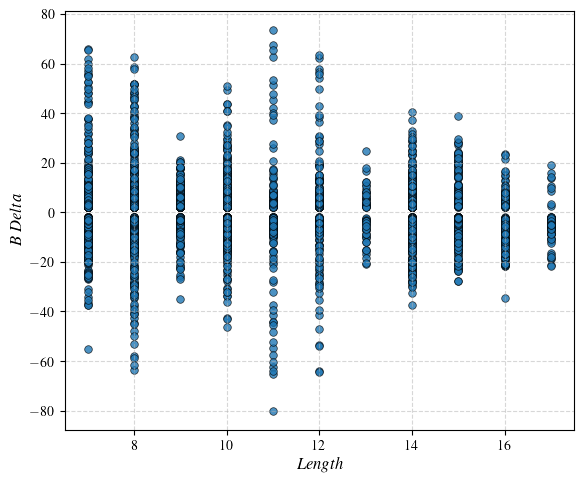

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def plot_scatter_publication(
    x, 
    y, 
    x_label="X-axis", 
    y_label="Y-axis", 
    title="Scatter Plot",
    save_path="scatter_plot.pdf"
):
    """
    Create a scatter plot of two variables using LaTeX fonts for publication.

    Args:
        x (array-like): Values for the x-axis.
        y (array-like): Values for the y-axis.
        x_label (str): Label for the x-axis.
        y_label (str): Label for the y-axis.
        title (str): Title of the plot.
        save_path (str): Path to save the PDF figure.
    """
    # Enable LaTeX font rendering
    plt.rcParams.update({
            "text.usetex": True,
            "font.family": "serif",
            "font.serif": ["Times"],
            "axes.labelsize": 12,
            "font.size": 12,
            "legend.fontsize": 10,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
        })

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(x, y, s=30, edgecolor='black', linewidth=0.5, alpha=0.8)

    ax.set_xlabel(f"${x_label}$")
    ax.set_ylabel(f"${y_label}$")
    ax.set_title(f"{title}", pad=10)

    ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout()
    fig.savefig(save_path, format="pdf", dpi=300)
    plt.show()

# Sample data
x = length
y = real_deltas

# Plot
plot_scatter_publication(
    x, y, 
    x_label="Length", 
    y_label="B \; Delta", 
    title="",
    save_path="/home/amirabbas-kazeminia/Projects/DeepRT/figures/delta_vs_length.pdf"
)

In [20]:
f_seqs = [pair[0] for pair in pairs]
F_seqs = [pair[1] for pair in pairs]

In [21]:
f_scores = model.predict(f_seqs)["B_scores"]
F_scores = model.predict(F_seqs)["B_scores"]

In [22]:
pred = F_scores - f_scores

In [23]:
acc = (np.array((pred>0))==(np.array(real_deltas)>0)).sum()

In [24]:
acc/len(real_deltas)

np.float64(0.6977707634641941)